# 📧 Email Spam Detection using Naive Bayes

## Task 7 - Machine Learning Internship

### Objective
Build an Email Spam Detection model using Natural Language Processing (NLP) and the Naive Bayes algorithm.

### Workflow
- Load the spam dataset
- Perform text preprocessing
- Convert text into numerical features using TF-IDF
- Train a Naive Bayes classifier
- Evaluate model performance
- Test the model with custom email messages

In [2]:
# Import required libraries

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Step 1: Load the Dataset
Load the SMS Spam Collection dataset and keep only the required columns.

In [3]:
df = pd.read_csv("dataset/spam.csv", encoding="latin-1")
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 2: Explore the Dataset
Check the size of the dataset and the number of spam and ham messages.

In [4]:
print("Dataset Shape:", df.shape)
print("\nLabel Distribution:\n")
print(df['label'].value_counts())

Dataset Shape: (5572, 2)

Label Distribution:

label
ham     4825
spam     747
Name: count, dtype: int64


## Step 3: Convert Labels into Numerical Values
- Ham → 0
- Spam → 1

In [5]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Step 4: Split the Dataset
Separate features and target variable, then split into training and testing datasets.

In [6]:
X = df['message']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 5: Convert Text into Numerical Features
Use TF-IDF Vectorization to transform text into machine-readable numerical vectors.

In [7]:
vectorizer = TfidfVectorizer(stop_words='english')
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

## Step 6: Train the Naive Bayes Classifier
Train a Multinomial Naive Bayes model using the TF-IDF features.

In [8]:
model = MultinomialNB()
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## Step 7: Make Predictions
Predict whether emails in the test set are spam or ham.

In [9]:
y_pred = model.predict(X_test)

## Step 8: Evaluate the Model
Measure the model performance using:
- Accuracy
- Classification Report
- Confusion Matrix

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 96.68 %

Classification Report

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



## Step 9: Visualize the Confusion Matrix
A confusion matrix shows the number of correct and incorrect predictions made by the classifier.

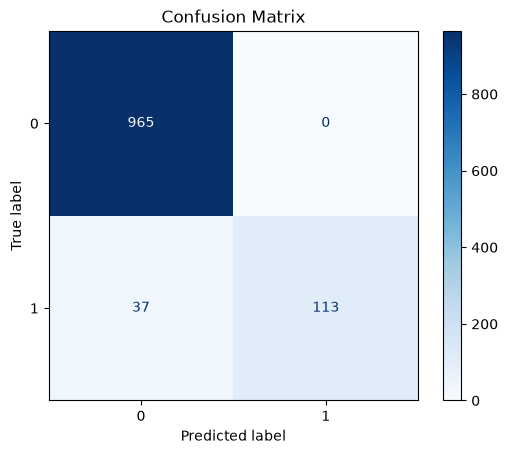

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Step 10: Save the Trained Model
Save the trained model and TF-IDF vectorizer for future predictions.

In [12]:
joblib.dump(model, "models/spam_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")
print("Model saved successfully.")

Model saved successfully.


## Step 11: Test the Model with Custom Email Messages
Use the trained model to classify new email messages as Spam or Ham.

In [13]:
model = joblib.load("models/spam_model.pkl")
vectorizer = joblib.load("models/tfidf_vectorizer.pkl")

In [19]:
def predict_email(text):
    text_vector = vectorizer.transform([text])

    prediction = model.predict(text_vector)[0]
    probability = model.predict_proba(text_vector)[0]

    print(f"\nEmail: {text}")

    if prediction == 1:
        print("Prediction: Spam 📧")
        print(f"Confidence: {probability[1]*100:.2f}%")
    else:
        print("Prediction: Ham ✅")
        print(f"Confidence: {probability[0]*100:.2f}%")

## Step 12: Sample Predictions
Test the classifier using some example email messages.

In [20]:
predict_email("Congratulations! You have won a free iPhone. Click here now.")
predict_email("Hey, are we still meeting for lunch tomorrow?")
predict_email("URGENT! Claim your ₹5000 reward now!")
predict_email("Please submit your assignment before 5 PM.")


Email: Congratulations! You have won a free iPhone. Click here now.
Prediction: Spam 📧
Confidence: 62.33%

Email: Hey, are we still meeting for lunch tomorrow?
Prediction: Ham ✅
Confidence: 99.82%

Email: URGENT! Claim your ₹5000 reward now!
Prediction: Spam 📧
Confidence: 93.39%

Email: Please submit your assignment before 5 PM.
Prediction: Ham ✅
Confidence: 88.24%


# Conclusion
In this project, an Email Spam Detection system was developed using the Multinomial Naive Bayes algorithm.
The text data was converted into numerical features using TF-IDF Vectorization, allowing the classifier to distinguish between spam and legitimate emails. The trained model achieved high accuracy and successfully classified custom email messages.
This project demonstrates the application of Natural Language Processing (NLP) techniques for text classification using Machine Learning.